# Earthkit Africa Flat Projection

Notebook Earthkit avec projection plate focalisée sur l'Afrique et une présentation proche d'une carte produit de type analyse.

In [1]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import earthkit
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

In [2]:
temperature = earthkit.data.from_source(
    'cds',
    'derived-era5-pressure-levels-daily-statistics',
    {
        'product_type': 'reanalysis',
        'variable': ['temperature'],
        'year': '2026',
        'month': ['03'],
        'day': ['01'],
        'pressure_level': ['1000'],
        'daily_statistic': 'daily_mean',
        'time_zone': 'utc+00:00',
        'frequency': '1_hourly',
    },
)

datetime_for_plot = '2026-03-01 (UTC)'

2026-04-06 15:48:43,689 INFO Request ID is b0df6570-86ca-4b4e-9094-0dd552b55bc2
2026-04-06 15:48:43,832 INFO status has been updated to accepted
2026-04-06 15:48:57,542 INFO status has been updated to successful


In [3]:
temperature_style = earthkit.plots.styles.Style(
    colors=[
        '#462255', '#5c2f8f', '#7c4fb0', '#c02fd6',
        '#6c7fb8', '#9db4d8', '#dfe8f6', '#fff3e3',
        '#ffd08a', '#ffa455', '#ff6b2d', '#ff3300',
        '#b30000', '#6d1f1f',
    ],
    levels=range(-40, 41, 2),
    extend='both',
    units='celsius',
)

# Flat projection centered on Africa.
crs = ccrs.LambertAzimuthalEqualArea(central_longitude=20, central_latitude=5)

/tmp/ipykernel_117640/1521726974.py:8: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(left=0.05, right=0.95, top=0.86, bottom=0.13)
/home/abdessamadelh/miniconda3/envs/atlas-env/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/abdessamadelh/miniconda3/envs/atlas-env/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Saved: /home/abdessamadelh/Documents/stage/Tests/c3s-atlas-main/book/customizing/overview-africa-flat-projection.png


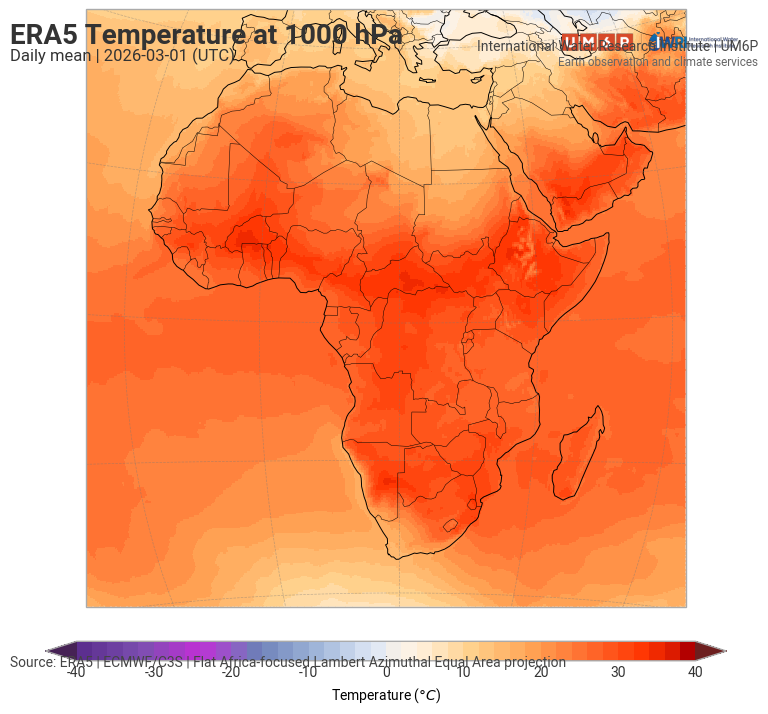

In [4]:
earthkit.plots.schema.figsize = (10, 8.6)

chart = earthkit.plots.Map(crs=crs)
chart.pcolormesh(temperature, style=temperature_style)
chart.legend(location='bottom', shrink=0.86)

fig = plt.gcf()
fig.subplots_adjust(left=0.05, right=0.95, top=0.86, bottom=0.13)
ax = plt.gca()

# Zoom on Africa with a bit of ocean margin.
ax.set_extent([-26, 62, -40, 42], crs=ccrs.PlateCarree())
ax.coastlines(resolution='110m', color='black', linewidth=0.7)
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.35)
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=False,
    linewidth=0.5,
    color='#777777',
    alpha=0.45,
    linestyle='--',
)

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'c3s_atlas').exists() and (path / 'book').exists()
)
logo_path = repo_root / 'book' / 'customizing' / 'data' / 'logo' / 'logo-um6p-iwri-transparent.png'

fig.text(
    0.03,
    0.975,
    'ERA5 Temperature at 1000 hPa',
    fontsize=20,
    fontweight='bold',
    ha='left',
    va='top',
)
fig.text(
    0.03,
    0.94,
    f'Daily mean | {datetime_for_plot}',
    fontsize=12,
    ha='left',
    va='top',
)

if logo_path.exists():
    logo = mpimg.imread(logo_path)
    ax_logo = fig.add_axes([0.72, 0.915, 0.22, 0.065])
    ax_logo.imshow(logo)
    ax_logo.axis('off')

fig.text(
    0.965,
    0.952,
    'International Water Research Institute | UM6P',
    fontsize=10,
    color='#444444',
    ha='right',
    va='top',
)
fig.text(
    0.965,
    0.928,
    'Earth observation and climate services',
    fontsize=8.5,
    color='#666666',
    ha='right',
    va='top',
)

fig.text(
    0.03,
    0.055,
    'Source: ERA5 | ECMWF/C3S | Flat Africa-focused Lambert Azimuthal Equal Area projection',
    fontsize=10,
    color='#444444',
    ha='left',
)

output_path = repo_root / 'book' / 'customizing' / 'overview-africa-flat-projection.png'
plt.savefig(output_path, dpi=220, bbox_inches='tight')
print('Saved:', output_path)
plt.show()